# Deep Learning for AI vs Human Text Detection

This notebook focuses on **Part 5 (FNN)** and **Part 6 (LSTM-based models)** of the Arabic AI-vs-Human text detection project. It also includes selected bonus experiments such as hyperparameter tuning, cross-validation, and ensemble testing.

## 1) Import Libraries and Set Random Seeds

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization,
    Embedding, LSTM, Bidirectional, Attention, GlobalAveragePooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


2026-05-29 18:43:03.400885: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780080183.762049     285 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780080183.851671     285 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780080184.704173     285 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780080184.704224     285 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780080184.704227     285 computation_placer.cc:177] computation placer alr

### 2) Load Processed Dataset

In [2]:
# Load the processed dataset
df = pd.read_csv("/kaggle/input/datasets/noorabushawar/with-stopwoords/text_preprocessed_dataset (1).csv")  # غيري هون: اكتبي اسم ملف البروسيسنج النهائي

## 3) Dataset Inspection and Label Encoding

In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (1494, 2)

Columns:
Index(['text_normalized', 'label'], dtype='object')

First 5 rows:


,text_normalized,label
0,مع زياده الاعتماد على الخدمات الرقميه اصبحت حم...,human_written
1,معظم الهجمات التي تحدث وتتم بسرعه وسهوله هي بس...,human_written
2,في ظل التطور التكنولوجي الكبير في هذا العصر وز...,human_written
3,يرتبط الامن السيبراني بالذكاء الاصطناعي ارتباط...,human_written
4,الامن السيبراني هو احد اهم المجالات في العصر ا...,human_written



Missing values:
text_normalized    0
label              0
dtype: int64


In [4]:
df["label"] = df["label"].astype(str).str.strip().str.lower()

label_mapping = {
    "human_written": 0,
    "ai_generated": 1
}

df["label_encoded"] = df["label"].map(label_mapping)

print("Original label distribution:")
print(df["label"].value_counts())

print("\nEncoded label distribution:")
print(df["label_encoded"].value_counts(dropna=False))

Original label distribution:
label
ai_generated     759
human_written    735
Name: count, dtype: int64

Encoded label distribution:
label_encoded
1    759
0    735
Name: count, dtype: int64


## 4) Select Text and Label Columns

In [5]:
TEXT_COLUMN = "text_normalized"
LABEL_COLUMN = "label_encoded"


In [6]:
# Remove rows with missing text or label values
df = df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN])

# Features and labels
X = df[TEXT_COLUMN].astype(str)
y = df[LABEL_COLUMN].astype(int).values

print("Number of samples:", len(X))
print("Labels distribution:")
print(pd.Series(y).value_counts())


Number of samples: 1494
Labels distribution:
1    759
0    735
Name: count, dtype: int64


## 5) Train/Test Split

A stratified split is used to preserve the Human/AI class distribution in both training and testing sets. The test set is kept separate and is not used during training or cross-validation.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\ny_train distribution:")
print(pd.Series(y_train).value_counts())
print("\ny_test distribution:")
print(pd.Series(y_test).value_counts())

Training samples: 1195
Testing samples: 299

y_train distribution:
1    607
0    588
Name: count, dtype: int64

y_test distribution:
1    152
0    147
Name: count, dtype: int64


## 6) Class Balance Analysis

Class weights are computed after the train/test split. These weights can be passed to deep learning models to reduce bias if class imbalance exists.

In [8]:
print("Training label distribution:")
print(pd.Series(y_train).value_counts())

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(zip(np.unique(y_train), class_weights))

print("Class weights:")
print(class_weights_dict)


Training label distribution:
1    607
0    588
Name: count, dtype: int64
Class weights:
{np.int64(0): np.float64(1.0161564625850341), np.int64(1): np.float64(0.984349258649094)}


## 7) Evaluation Function

In [9]:
results = []

def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="binary", zero_division=0)
    recall = recall_score(y_true, y_pred, average="binary", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    print(f"Results for {model_name}")
    print("-" * 40)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Human", "AI"],
        zero_division=0
    ))

# Part 5 — Feed-Forward Neural Networks (FNN)

This part implements FNN models using two input representations:
1. TF-IDF vectors
2. Averaged Word2Vec vectors

For binary classification, the output layer uses one sigmoid neuron, which is the binary equivalent of a two-class softmax setup.

## 8) TF-IDF Vectorization

In [10]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train).toarray()
X_test_tfidf = tfidf_vectorizer.transform(X_test).toarray()

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (1195, 5000)
TF-IDF test shape: (299, 5000)


## 9) Build FNN Model with TF-IDF Features

In [13]:
from sklearn.model_selection import KFold
def create_fnn_model():
    model = Sequential([
        Dense(256, activation="relu", input_shape=(X_train_tfidf.shape[1],)),
        BatchNormalization(),
        Dropout(0.4),

        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),

        Dense(2, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, val_idx in kfold.split(X_train_tfidf):
    model = create_fnn_model()

    model.fit(
        X_train_tfidf[train_idx],
        y_train[train_idx],
        validation_data=(X_train_tfidf[val_idx], y_train[val_idx]),
        epochs=30,
        batch_size=32,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test_tfidf, y_test, verbose=0)
    cv_scores.append(accuracy)

print("Cross-Validation Accuracies:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print("Std Accuracy:", np.std(cv_scores))

Cross-Validation Accuracies: [0.8428093791007996, 0.8494983315467834, 0.8394649028778076, 0.8394649028778076, 0.8428093791007996]
Mean Accuracy: 0.8428093791007996
Std Accuracy: 0.003663690140744731


In [15]:
fnn_tfidf_model = create_fnn_model()

fnn_tfidf_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,330 (5.05 MB)

 Trainable params: 1,322,434 (5.04 MB)

 Non-trainable params: 896 (3.50 KB)

## 10) Train FNN + TF-IDF

In [16]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_fnn_tfidf = fnn_tfidf_model.fit(
    X_train_tfidf,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    class_weight=class_weights_dict,

    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5807 - loss: 0.9884 - val_accuracy: 0.7741 - val_loss: 0.6832
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8525 - loss: 0.3380 - val_accuracy: 0.4854 - val_loss: 0.6769
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9058 - loss: 0.2600 - val_accuracy: 0.4854 - val_loss: 0.6721
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9550 - loss: 0.1112 - val_accuracy: 0.4895 - val_loss: 0.6635
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9616 - loss: 0.0998 - val_accuracy: 0.5021 - val_loss: 0.6423
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9836 - loss: 0.0543 - val_accuracy: 0.6067 - val_loss: 0.5990
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9889 - loss: 0.0350 - val_accuracy: 0.6946 - val_loss: 0.5598
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9907 - loss: 0.0353 - val_accuracy: 0.7573 - v

## 11) Evaluate FNN + TF-IDF

In [17]:
y_pred_prob = fnn_tfidf_model.predict(X_test_tfidf)
y_pred_fnn_tfidf = np.argmax(y_pred_prob, axis=1)

evaluate_model("FNN + TF-IDF", y_test, y_pred_fnn_tfidf)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Results for FNN + TF-IDF
----------------------------------------
Accuracy : 0.8260869565217391
Precision: 0.8378378378378378
Recall   : 0.8157894736842105
F1-score : 0.8266666666666667

Classification Report:
              precision    recall  f1-score   support

       Human       0.81      0.84      0.83       147
          AI       0.84      0.82      0.83       152

    accuracy                           0.83       299
   macro avg       0.83      0.83      0.83       299
weighted avg       0.83      0.83      0.83       299



## 12) Plot FNN + TF-IDF Training Curves

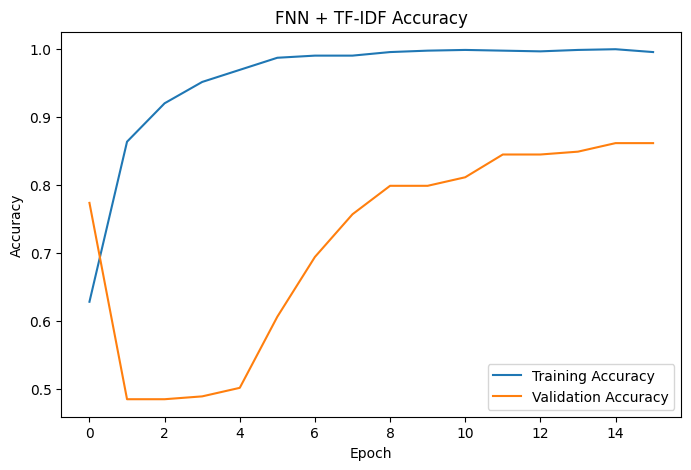

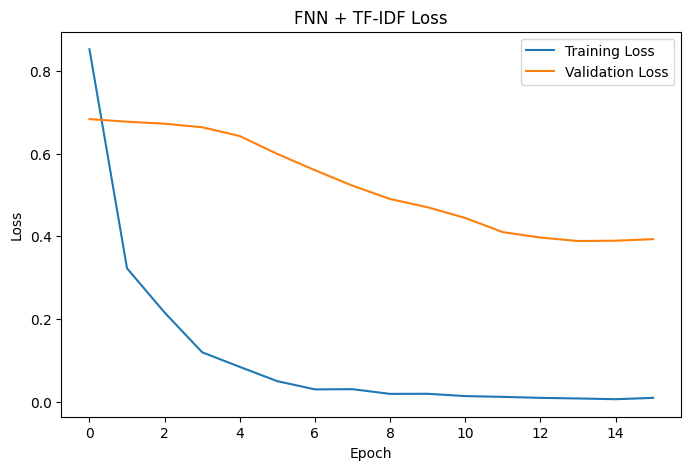

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(history_fnn_tfidf.history["accuracy"], label="Training Accuracy")
plt.plot(history_fnn_tfidf.history["val_accuracy"], label="Validation Accuracy")
plt.title("FNN + TF-IDF Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_fnn_tfidf.history["loss"], label="Training Loss")
plt.plot(history_fnn_tfidf.history["val_loss"], label="Validation Loss")
plt.title("FNN + TF-IDF Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 13) Train Word2Vec Representation

In [19]:
from gensim.models import Word2Vec

# Tokenize text for Word2Vec
X_train_tokens = [text.split() for text in X_train]
X_test_tokens = [text.split() for text in X_test]

print("Example tokenized text:")
print(X_train_tokens[0][:15])

Example tokenized text:
['التغذيه', 'السليمه', 'هي', 'الوقود', 'الحقيقي', 'الذي', 'يدفع', 'عجله', 'الحياه', 'الصحيه', 'ولا', 'يمكن', 'تصور', 'نمط', 'حياه']


In [20]:
def average_word2vec(tokens, model, vector_size):
    vectors = []
    
    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])
    
    if len(vectors) == 0:
        return np.zeros(vector_size)
    
    return np.mean(vectors, axis=0)

In [21]:
word2vec_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

print("Word2Vec vocabulary size:", len(word2vec_model.wv))

Word2Vec vocabulary size: 10213


In [22]:
VECTOR_SIZE = 100

X_train_w2v = np.array([
    average_word2vec(tokens, word2vec_model, VECTOR_SIZE)
    for tokens in X_train_tokens
])

X_test_w2v = np.array([
    average_word2vec(tokens, word2vec_model, VECTOR_SIZE)
    for tokens in X_test_tokens
])

print("Word2Vec train shape:", X_train_w2v.shape)
print("Word2Vec test shape:", X_test_w2v.shape)

Word2Vec train shape: (1195, 100)
Word2Vec test shape: (299, 100)


## 14) Build FNN Model with Averaged Word2Vec Features

In [23]:

fnn_w2v_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_w2v.shape[1],)),
    Dropout(0.4),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(2, activation="softmax")
])

fnn_w2v_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fnn_w2v_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,330 (91.13 KB)

 Trainable params: 23,330 (91.13 KB)

 Non-trainable params: 0 (0.00 B)

## 15) Train FNN + Averaged Word2Vec

In [24]:
early_stop_w2v = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_fnn_w2v = fnn_w2v_model.fit(
    X_train_w2v,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop_w2v],
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5318 - loss: 0.6869 - val_accuracy: 0.6611 - val_loss: 0.6689
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6328 - loss: 0.6595 - val_accuracy: 0.6862 - val_loss: 0.6307
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6506 - loss: 0.6376 - val_accuracy: 0.6904 - val_loss: 0.5991
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7091 - loss: 0.5794 - val_accuracy: 0.7029 - val_loss: 0.5743
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7115 - loss: 0.5709 - val_accuracy: 0.7280 - val_loss: 0.5571
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7466 - loss: 0.5538 - val_accuracy: 0.7280 - val_loss: 0.5537
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7213 - loss: 0.5493 - val_accuracy: 0.7364 - val_loss: 0.5396
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7496 - loss: 0.5325 - val_accuracy: 0.7238 - val_loss

## 16) Evaluate FNN + Averaged Word2Vec

In [25]:
y_pred_prob_w2v = fnn_w2v_model.predict(X_test_w2v)
y_pred_fnn_w2v = np.argmax(y_pred_prob_w2v, axis=1)

evaluate_model("FNN + Averaged Word2Vec", y_test, y_pred_fnn_w2v)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Results for FNN + Averaged Word2Vec
----------------------------------------
Accuracy : 0.7591973244147158
Precision: 0.7298850574712644
Recall   : 0.8355263157894737
F1-score : 0.7791411042944786

Classification Report:
              precision    recall  f1-score   support

       Human       0.80      0.68      0.74       147
          AI       0.73      0.84      0.78       152

    accuracy                           0.76       299
   macro avg       0.76      0.76      0.76       299
weighted avg       0.76      0.76      0.76       299



# Part 6 — LSTM-Based Models

This part converts text into tokenized and padded sequences, then trains an LSTM with Attention and an optional BiLSTM model.

## 17) Tokenization for LSTM

In [26]:
# LSTM settings
MAX_WORDS = 20000

text_lengths = [len(str(text).split()) for text in X_train]
MAX_LEN = int(np.percentile(text_lengths, 95))

print("Dynamic MAX_LEN =", MAX_LEN)

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

Dynamic MAX_LEN = 222


# 18) Padding

In [27]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Train padded shape:", X_train_pad.shape)
print("Test padded shape:", X_test_pad.shape)

Train padded shape: (1195, 222)
Test padded shape: (299, 222)


## 19) Build LSTM with Attention

In [28]:
VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)
EMBEDDING_DIM = 128

print("VOCAB_SIZE =", VOCAB_SIZE)
print("EMBEDDING_DIM =", EMBEDDING_DIM)

VOCAB_SIZE = 20000
EMBEDDING_DIM = 128


In [32]:
input_layer = Input(shape=(MAX_LEN,))
embedding_layer = Embedding(VOCAB_SIZE, EMBEDDING_DIM)(input_layer)

lstm_1 = LSTM(128, return_sequences=True)(embedding_layer)
drop_1 = Dropout(0.3)(lstm_1)

lstm_2 = LSTM(64, return_sequences=True)(drop_1)
drop_2 = Dropout(0.3)(lstm_2)

attention_layer = Attention()([drop_2, drop_2])
pooling_layer = GlobalAveragePooling1D()(attention_layer)

output_layer = Dense(2, activation="softmax")(pooling_layer)

lstm_model = Model(inputs=input_layer, outputs=output_layer)

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 222)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 222, 128)  │  2,560,000 │ input_layer_14[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 222, 128)  │    131,584 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_41          │ (None, 222, 128)  │          0 │ lstm_2[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 222, 64)   │     49,408 │ dropout_41[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_42          │ (None, 222, 64)   │          0 │ lstm_3[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 222, 64)   │          0 │ dropout_42[0][0], │
│ (Attention)         │                   │            │ dropout_42[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ attention_1[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 2)         │        130 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,741,122 (10.46 MB)

 Trainable params: 2,741,122 (10.46 MB)

 Non-trainable params: 0 (0.00 B)

## 20) Train LSTM 

In [33]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_lstm = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop_lstm],
    verbose=1
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 406ms/step - accuracy: 0.5347 - loss: 0.6846 - val_accuracy: 0.7699 - val_loss: 0.5346
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 388ms/step - accuracy: 0.8578 - loss: 0.3843 - val_accuracy: 0.8075 - val_loss: 0.4657
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 390ms/step - accuracy: 0.9350 - loss: 0.1945 - val_accuracy: 0.8243 - val_loss: 0.4648
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 383ms/step - accuracy: 0.9670 - loss: 0.1195 - val_accuracy: 0.8117 - val_loss: 0.9478
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 383ms/step - accuracy: 0.9656 - loss: 0.1444 - val_accuracy: 0.8285 - val_loss: 0.6604


## 21) Evaluate LSTM

In [34]:
y_pred_prob_lstm = lstm_model.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_prob_lstm, axis=1)
evaluate_model("LSTM", y_test, y_pred_lstm)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step
Results for LSTM
----------------------------------------
Accuracy : 0.8160535117056856
Precision: 0.8169934640522876
Recall   : 0.8223684210526315
F1-score : 0.819672131147541

Classification Report:
              precision    recall  f1-score   support

       Human       0.82      0.81      0.81       147
          AI       0.82      0.82      0.82       152

    accuracy                           0.82       299
   macro avg       0.82      0.82      0.82       299
weighted avg       0.82      0.82      0.82       299



## 22) Plot LSTM Training Curves

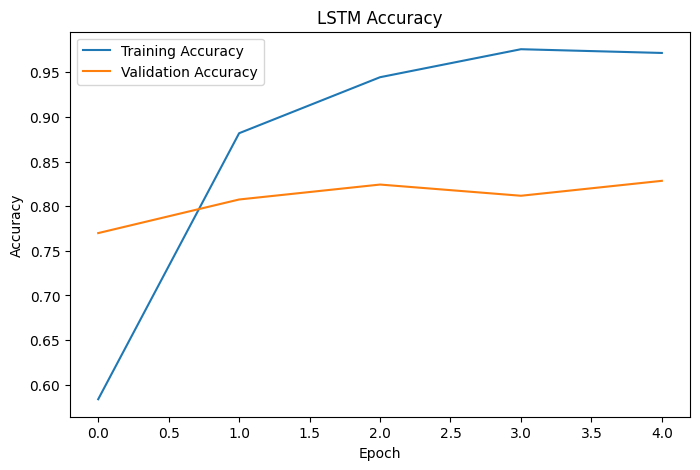

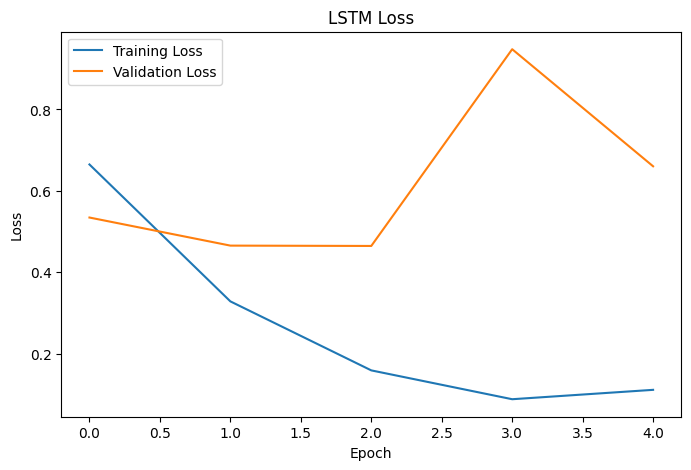

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history["accuracy"], label="Training Accuracy")
plt.plot(history_lstm.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history["loss"], label="Training Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")
plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 23) Confusion Matrix for LSTM

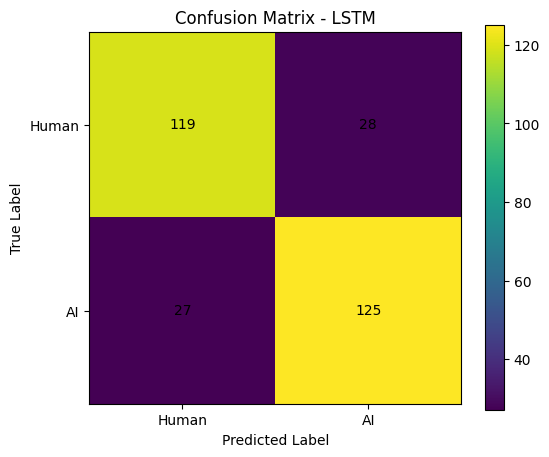

In [36]:
cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Human", "AI"])
plt.yticks([0, 1], ["Human", "AI"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## 24) Build BiLSTM Model

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)
EMBEDDING_DIM = 128

bilstm_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    Bidirectional(LSTM(64)),
    Dropout(0.4),

    Dense(32, activation="relu"),
    Dropout(0.3),

    Dense(2, activation="softmax")
])

bilstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 222, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,663,010 (10.16 MB)

 Trainable params: 2,663,010 (10.16 MB)

 Non-trainable params: 0 (0.00 B)

## 25) Train BiLSTM

In [38]:
early_stop_bilstm = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr_bilstm = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history_bilstm = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop_bilstm, reduce_lr_bilstm],
    verbose=1
)


Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.5330 - loss: 0.6893 - val_accuracy: 0.7573 - val_loss: 0.6554 - learning_rate: 0.0010
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - accuracy: 0.7778 - loss: 0.5447 - val_accuracy: 0.8117 - val_loss: 0.4192 - learning_rate: 0.0010
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.9287 - loss: 0.2288 - val_accuracy: 0.8326 - val_loss: 0.4931 - learning_rate: 0.0010
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9727 - loss: 0.0856
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.9729 - loss: 0.0852 - val_accuracy: 0.8452 - val_loss: 0.5098 - learning_rate: 0.0010
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.9934 - loss: 0.0345 - val_accuracy: 0.8368 - val_loss: 0.6272 - learning_rate: 5.0000e-04


## 26) Evaluate BiLSTM

In [39]:
y_pred_prob_bilstm = bilstm_model.predict(X_test_pad)
y_pred_bilstm = np.argmax(y_pred_prob_bilstm, axis=1)

evaluate_model("BiLSTM", y_test, y_pred_bilstm)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
Results for BiLSTM
----------------------------------------
Accuracy : 0.782608695652174
Precision: 0.8
Recall   : 0.7631578947368421
F1-score : 0.7811447811447811

Classification Report:
              precision    recall  f1-score   support

       Human       0.77      0.80      0.78       147
          AI       0.80      0.76      0.78       152

    accuracy                           0.78       299
   macro avg       0.78      0.78      0.78       299
weighted avg       0.78      0.78      0.78       299



# Final Deep Learning Comparison

In [40]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1-score", ascending=False)
results_df = results_df.drop_duplicates(subset=["Model"], keep="first").reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-score
0,FNN + TF-IDF,0.826087,0.837838,0.815789,0.826667
1,LSTM,0.816054,0.816993,0.822368,0.819672
2,BiLSTM,0.782609,0.800000,0.763158,0.781145
3,FNN + Averaged Word2Vec,0.759197,0.729885,0.835526,0.779141


In [41]:
results_df.to_csv("deep_learning_results.csv", index=False)  

### 31) Plot Final Comparison

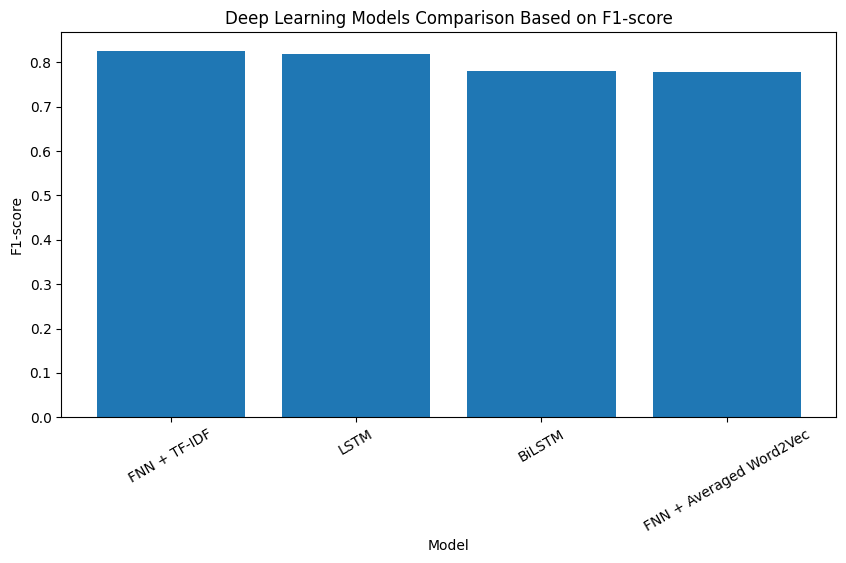

In [42]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["F1-score"])
plt.title("Deep Learning Models Comparison Based on F1-score")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=30)
plt.show()

# Bonus A — KerasTuner for FNN Hyperparameter Tuning

This optional section searches for stronger FNN hyperparameters. It is placed after the main models because it can take longer to execute.

In [44]:
!pip install -q keras-tuner

import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_fnn_model(hp):
    model = Sequential()

    model.add(Dense(
        units=hp.Int("units_1", min_value=64, max_value=256, step=64),
        activation="relu",
        input_shape=(X_train_tfidf.shape[1],)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_1", 0.2, 0.5, step=0.1)))

    model.add(Dense(
        units=hp.Int("units_2", min_value=32, max_value=128, step=32),
        activation="relu"
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_2", 0.2, 0.4, step=0.1)))

    model.add(Dense(2, activation="softmax"))
    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


tuner = kt.Hyperband(
    build_fnn_model,
    objective="val_accuracy",
    max_epochs=30,
    factor=3,
    directory="keras_tuner_results",
    project_name="fnn_tfidf_tuning"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

tuner.search(
    X_train_tfidf,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best units_1:", best_hps.get("units_1"))
print("Best dropout_1:", best_hps.get("dropout_1"))
print("Best units_2:", best_hps.get("units_2"))
print("Best dropout_2:", best_hps.get("dropout_2"))
print("Best learning_rate:", best_hps.get("learning_rate"))

Trial 90 Complete [00h 00m 16s]
val_accuracy: 0.8200836777687073

Best val_accuracy So Far: 0.8702929019927979
Total elapsed time: 00h 09m 23s
Best units_1: 192
Best dropout_1: 0.30000000000000004
Best units_2: 96
Best dropout_2: 0.30000000000000004
Best learning_rate: 0.01


In [45]:
best_fnn_model = tuner.hypermodel.build(best_hps)

history_best_fnn = best_fnn_model.fit(
    X_train_tfidf,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

best_fnn_loss, best_fnn_accuracy = best_fnn_model.evaluate(
    X_test_tfidf,
    y_test,
    verbose=0
)

y_pred_prob_best_fnn = best_fnn_model.predict(X_test_tfidf)
y_pred_best_fnn = np.argmax(y_pred_prob_best_fnn, axis=1)

evaluate_model("Tuned FNN + TF-IDF", y_test, y_pred_best_fnn)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6777 - loss: 0.8342 - val_accuracy: 0.8201 - val_loss: 0.5771
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8871 - loss: 0.2576 - val_accuracy: 0.8368 - val_loss: 0.4176
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9648 - loss: 0.1003 - val_accuracy: 0.8368 - val_loss: 0.3874
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9934 - loss: 0.0259 - val_accuracy: 0.8494 - val_loss: 0.3724
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9983 - loss: 0.0125 - val_accuracy: 0.8201 - val_loss: 0.4008
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9955 - loss: 0.0095 - val_accuracy: 0.8201 - val_loss: 0.4253
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9937 - loss: 0.0158 - val_accuracy: 0.8243 - val_loss: 0.4557
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Results for Tuned FNN + TF-IDF
----------------------------------------

# Bonus B — Classical ML Tuning and Ensemble Baseline

This section adds tuned SVM/RF classical baselines using TF-IDF features, then tests whether a VotingClassifier improves performance.

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

param_grid_svm  = {
    "C": [0.01, 0.1, 1, 10, 100, 1000],
    "gamma": ["scale", "auto", 1e-4, 1e-3, 1e-2, 0.1, 1],
    "kernel": ["rbf"]
}

grid_svm = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid_svm,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_tfidf, y_train)

print("Best SVM Params:", grid_svm.best_params_)
print("Best CV Score:", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_
y_pred_svm_grid = best_svm.predict(X_test_tfidf)

print("\nTuned SVM Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, y_pred_svm_grid))
print("Precision:", precision_score(y_test, y_pred_svm_grid, average="weighted", zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_svm_grid, average="weighted", zero_division=0))
print("F1-score :", f1_score(y_test, y_pred_svm_grid, average="weighted", zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_grid, target_names=["Human", "AI"], zero_division=0))

Fitting 3 folds for each of 42 candidates, totalling 126 fits
Best SVM Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score: 0.8567863313318175

Tuned SVM Results
----------------------------------------
Accuracy : 0.8662207357859532
Precision: 0.869259824017068
Recall   : 0.8662207357859532
F1-score : 0.8658210807513514

Classification Report:
              precision    recall  f1-score   support

       Human       0.90      0.82      0.86       147
          AI       0.84      0.91      0.87       152

    accuracy                           0.87       299
   macro avg       0.87      0.87      0.87       299
weighted avg       0.87      0.87      0.87       299



In [47]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_tfidf, y_train)

print("Best RF Params:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_
y_pred_rf_grid = best_rf.predict(X_test_tfidf)

print("\nTuned Random Forest Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, y_pred_rf_grid))
print("Precision:", precision_score(y_test, y_pred_rf_grid, average="weighted", zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_rf_grid, average="weighted", zero_division=0))
print("F1-score :", f1_score(y_test, y_pred_rf_grid, average="weighted", zero_division=0))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best RF Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.8516335154797199

Tuned Random Forest Results
----------------------------------------
Accuracy : 0.8260869565217391
Precision: 0.8305477904002855
Recall   : 0.8260869565217391
F1-score : 0.8252768025924926


In [48]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ensemble_model = VotingClassifier(
    estimators=[
        ("svm", best_svm),
        ("rf", best_rf)
    ],
    voting="hard"
)

ensemble_model.fit(X_train_tfidf, y_train)

y_pred_ensemble = ensemble_model.predict(X_test_tfidf)

print("Ensemble Accuracy:", accuracy_score(y_test, y_pred_ensemble))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble, target_names=["Human", "AI"], zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ensemble))

Ensemble Accuracy: 0.8461538461538461

Classification Report:
              precision    recall  f1-score   support

       Human       0.85      0.84      0.84       147
          AI       0.84      0.86      0.85       152

    accuracy                           0.85       299
   macro avg       0.85      0.85      0.85       299
weighted avg       0.85      0.85      0.85       299


Confusion Matrix:
[[123  24]
 [ 22 130]]


## Bonus: Data Augmentation

To further improve model generalization, several text data augmentation techniques can be explored in future work:

* Back Translation
* Synonym Replacement
* Random Word Insertion
* Random Word Deletion

These techniques can increase training data diversity and potentially improve the performance of deep learning models. However, they were not applied in the current implementation because the dataset is already relatively balanced and augmentation may alter the linguistic characteristics needed to distinguish between human-written and AI-generated text.
